In [1]:
import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle
import matplotlib.pyplot as plt

from scoobscc.math_module import xp, xcipy, ensure_np_array
from scoobscc import utils
from scoobscc import dm
from scoobscc import scc_sim as scc
import scoobscc.scoob_model as scoobm

wfe_data = utils.load_pickle('/home/derbyk/src/scoob-scc/data_sim/example_wfe_data.pkl')

/home/derbyk/miniconda3/envs/py310-stp-env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
/home/derbyk/miniconda3/envs/py310-stp-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-28 12:07:38,833	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


SCoOB interface does not have the required packages to operate.


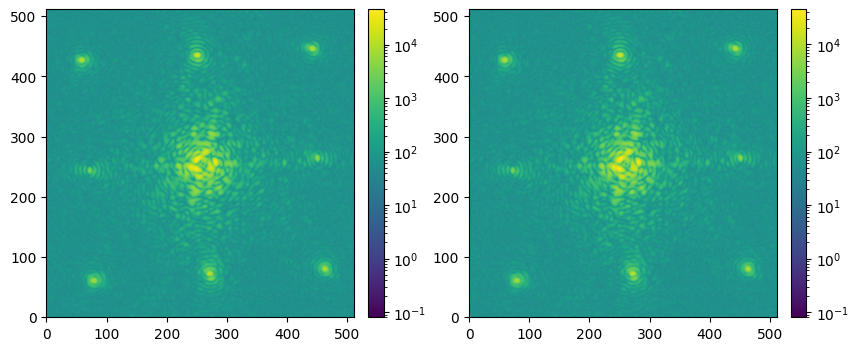

In [22]:
im_unmod = fits.getdata('/home/derbyk/src/scoob-scc/data_exp/20250527_init_test/im_unmod.fits')
im_mod = fits.getdata('/home/derbyk/src/scoob-scc/data_exp/20250527_init_test/im_mod.fits') 

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(im_unmod, norm='log')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(122)
plt.imshow(im_mod, norm='log')
plt.colorbar(fraction=0.046, pad=0.04)

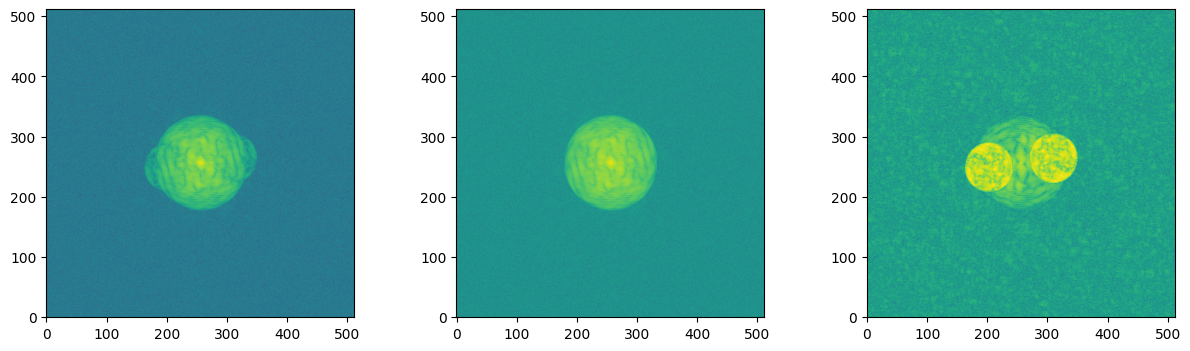

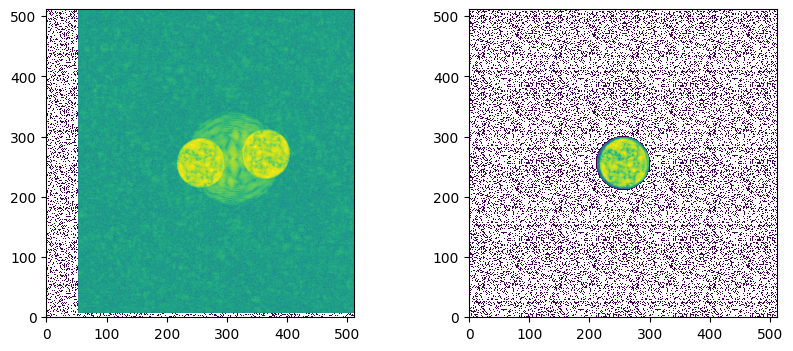

In [28]:
diam_window=0.17
shift = (7, 54)

fft_mod = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(im_mod), norm='ortho'))
fft_unmod = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(im_unmod), norm='ortho'))
fft_diff = fft_mod - fft_unmod


plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(xp.abs(fft_mod).get(), norm='log')
plt.subplot(132)
plt.imshow(xp.abs(fft_unmod).get(), norm='log')
plt.subplot(133)
plt.imshow(xp.abs(fft_diff).get(), norm='log')

fft_shifted = xcipy.ndimage.shift(fft_diff, shift)

x, y = xp.meshgrid(xp.linspace(-1, 1, fft_shifted.shape[0]), xp.linspace(-1, 1, fft_shifted.shape[0]))
r = xp.sqrt(x ** 2 + y ** 2)
mask = r < diam_window

fft_masked = fft_shifted * mask

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(xp.abs(fft_shifted).get(), norm='log')
plt.subplot(122)
plt.imshow(xp.abs(fft_masked).get(), norm='log')

estimate = xp.fft.ifftshift(xp.fft.fft2(xp.fft.fftshift(fft_masked), norm='ortho'))
    # estimate /= np.sqrt(scc_reference)

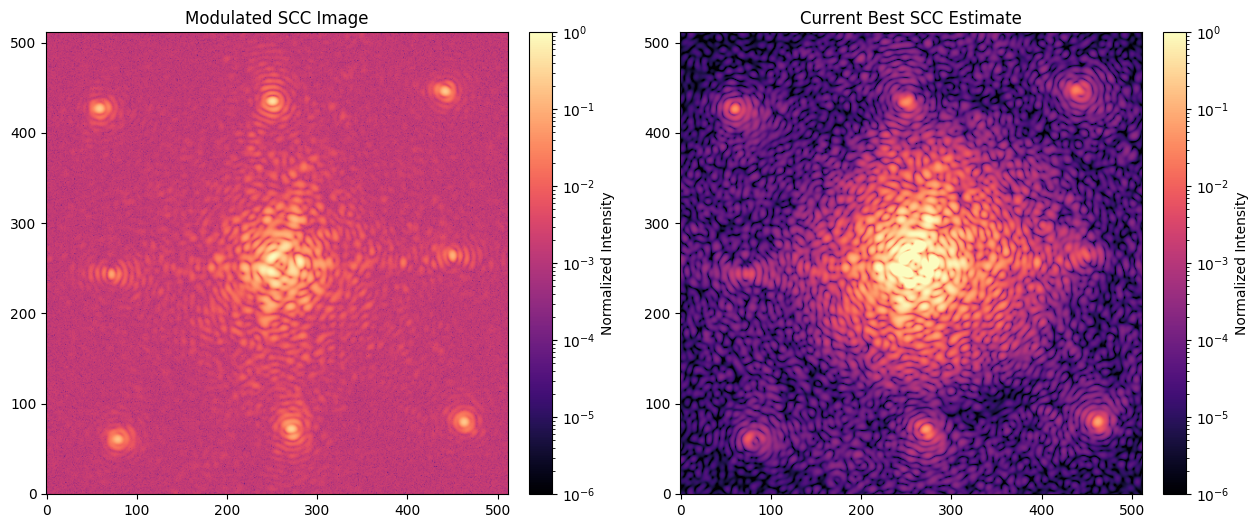

In [60]:
plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.title('Modulated SCC Image')
plt.imshow(im_unmod / im_unmod.max(), norm='log', vmin=1e-6, vmax=1, cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Normalized Intensity')
plt.subplot(122)
plt.title('Current Best SCC Estimate')
plt.imshow(xp.abs(estimate).get() ** 2 / im_unmod.max(), norm='log', vmin=1e-6, vmax=1, cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Normalized Intensity')

sigma:
0.1911392405063291
alpha:
2.4285714285714284


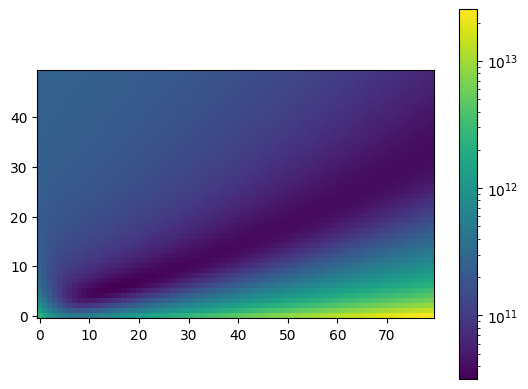

In [71]:
alphas = xp.linspace(1, 15, 50)
sigmas = xp.linspace(0.15, 0.4, 80)

mse_vals = xp.zeros((len(alphas), len(sigmas)))

x, y = xp.meshgrid(xp.linspace(-0.5, 0.5, 512), xp.linspace(-0.5, 0.5, 512))
r = xp.sqrt(x ** 2 + y ** 2)

for i, alpha in enumerate(alphas):
    for j, sigma in enumerate(sigmas):
        gauss = alpha / (2 * xp.pi * sigma ** 2) * xp.exp(-1 * (r ** 2) / (2 * sigma ** 2))
        norm_estimate = estimate / xp.sqrt(gauss)
        check = xp.abs(norm_estimate).get() ** 2 
        mse_vals[i, j] = np.sum((check - im_unmod) ** 2)

y_ind, x_ind = np.unravel_index(np.argmin(mse_vals), mse_vals.shape)

print('sigma:')
print(sigmas[int(x_ind)])
print('alpha:')
print(alphas[int(y_ind)])

plt.imshow(mse_vals.get(), norm='log')
plt.colorbar()

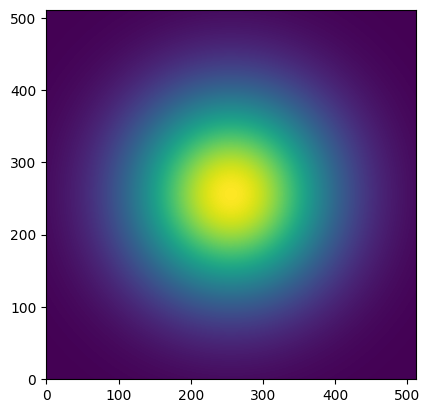

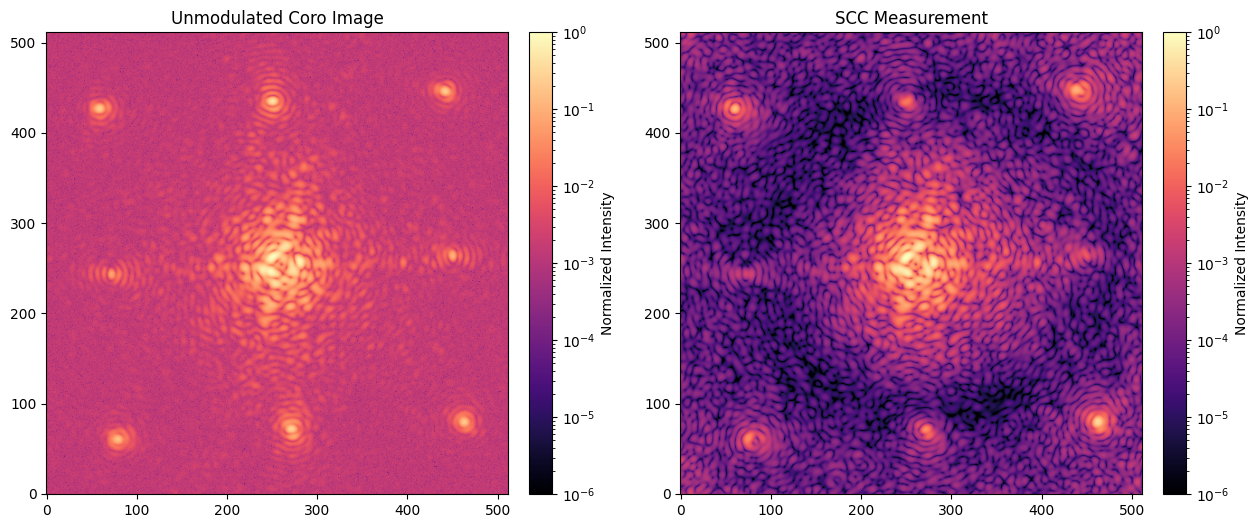

In [75]:
alpha = 2.4285714285714284
sigma = 0.1911392405063291

x, y = xp.meshgrid(xp.linspace(-0.5, 0.5, 512), xp.linspace(-0.5, 0.5, 512))
r = xp.sqrt(x ** 2 + y ** 2)

gauss = alpha / (2 * xp.pi * sigma ** 2) * xp.exp(-1 * (r ** 2) / (2 * sigma ** 2))

plt.figure()
plt.imshow(gauss.get())

norm_estimate = estimate / xp.sqrt(gauss)

plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.title('Unmodulated Coro Image')
plt.imshow(im_unmod / im_unmod.max(), norm='log', vmin=1e-6, vmax=1, cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Normalized Intensity')
plt.subplot(122)
plt.title('SCC Measurement')
plt.imshow(xp.abs(norm_estimate).get() ** 2 / im_unmod.max(), norm='log', vmin=1e-6, vmax=1, cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Normalized Intensity')